# Proyecto Final - Clasificación de Provincias a partir de Placas Vehiculares

**Maestría en Inteligencia Artificial - Visión Artificial**

## Objetivo
Entrenar un modelo de clasificación de imágenes capaz de predecir la **provincia del Ecuador**
a la que pertenece una placa vehicular, usando la **primera letra** de la placa como clase.

## Enfoque general
En este notebook se realiza el flujo completo del proyecto:

1. Carga y exploración del dataset.
2. Preparación de `DataLoader`.
3. Construcción del modelo.
4. Entrenamiento y validación.
5. Visualización de métricas.
6. Prueba con imágenes clasificadas.
7. Guardado del modelo entrenado en formato `.pth`.

## Nota
Este notebook utiliza los módulos implementados en la carpeta `src/`:

- `src/dataset.py`
- `src/model.py`
- `src/utils.py`
- `src/generate_dataset.py`


## 1. Importación de librerías

En esta sección importamos:

- librerías generales de Python,
- PyTorch,
- utilidades para visualización,
- y los archivos del proyecto que creamos en `src/`.


In [1]:
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# =========================================================
# Agregar la raíz del proyecto al PATH
# =========================================================
# Esto permite importar módulos desde la carpeta src/
# aunque estemos ejecutando el notebook desde notebooks/
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

# =========================================================
# Importar módulos propios del proyecto
# =========================================================
from src.dataset import (
    PlateProvinceDataset,
    train_transforms,
    eval_transforms,
    INDEX_TO_PROVINCE,
    INDEX_TO_LETTER,
    LETTER_TO_PROVINCE,
)
from src.model import build_model, get_device
from src.utils import (
    train_model,
    plot_training_history,
    load_model_weights,
    show_predictions,
)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Configuración inicial

Aquí definimos:

- semillas aleatorias para reproducibilidad,
- rutas del dataset,
- hiperparámetros iniciales de entrenamiento.

Esto ayuda a que el experimento sea más ordenado y defendible.


In [2]:
# =========================================================
# Fijar semillas para reproducibilidad
# =========================================================
# Esto ayuda a obtener resultados similares entre ejecuciones.
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# =========================================================
# Rutas del proyecto
# =========================================================
TRAIN_DIR = os.path.join(project_root, "data", "raw", "synthethic_plates", "train")
TEST_DIR = os.path.join(project_root, "data", "raw", "synthethic_plates", "test")
MODEL_SAVE_PATH = os.path.join(project_root, "outputs", "models", "best_model.pth")
FIGURES_DIR = os.path.join(project_root, "outputs", "figures")

# =========================================================
# Hiperparámetros iniciales
# =========================================================
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
NUM_CLASSES = 24

# Detectar dispositivo
device = get_device()

print("Dispositivo:", device)
print("Train dir:", TRAIN_DIR)
print("Test dir: ", TEST_DIR)
print("Modelo se guardará en:", MODEL_SAVE_PATH)

Dispositivo: cuda
Train dir: /home/cwvaldezp/Proyectos/VisionArtificial/vision-artificial-proyecto-final/data/raw/synthethic_plates/train
Test dir:  /home/cwvaldezp/Proyectos/VisionArtificial/vision-artificial-proyecto-final/data/raw/synthethic_plates/test
Modelo se guardará en: /home/cwvaldezp/Proyectos/VisionArtificial/vision-artificial-proyecto-final/outputs/models/best_model.pth


## 3. Carga del dataset

Vamos a crear dos datasets:

- uno de entrenamiento con `train_transforms`,
- uno de evaluación con `eval_transforms`.

La clase `PlateProvinceDataset` toma la **primera letra del nombre del archivo**
para convertirla en la clase de provincia.


In [3]:
# =========================================================
# Crear datasets
# =========================================================
train_dataset = PlateProvinceDataset(
    image_dir=TRAIN_DIR,
    transform=train_transforms,
    exclude_invalid=True
)

test_dataset = PlateProvinceDataset(
    image_dir=TEST_DIR,
    transform=eval_transforms,
    exclude_invalid=True
)

print(f"✅ Total imágenes de entrenamiento: {len(train_dataset)}")
print(f"✅ Total imágenes de prueba:        {len(test_dataset)}")

✅ Total imágenes de entrenamiento: 15973
✅ Total imágenes de prueba:        4027


## 4. Visualización rápida del dataset

Antes de entrenar, es importante inspeccionar algunas imágenes para verificar:

- que el dataset se cargó correctamente,
- que las dimensiones son razonables,
- y que las etiquetas corresponden a la provincia esperada.


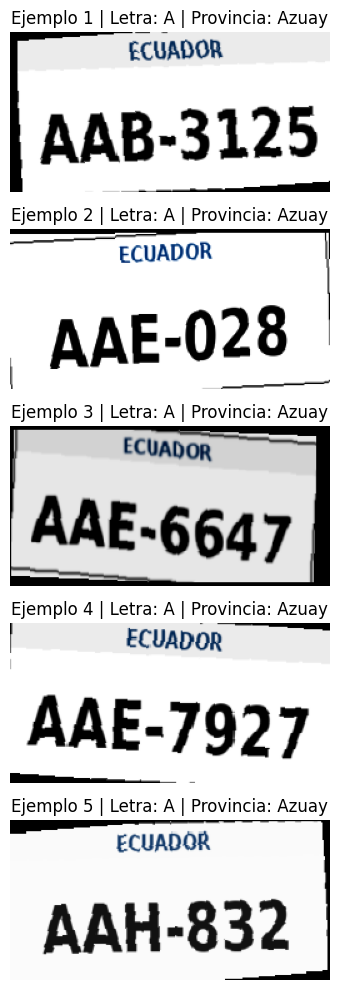

In [4]:
# =========================================================
# Mostrar algunas imágenes del dataset
# =========================================================
num_examples = 5

plt.figure(figsize=(14, 10))

for i in range(num_examples):
    image, label = train_dataset[i]

    # Convertir tensor [C, H, W] a formato [H, W, C] para matplotlib
    image_np = image.permute(1, 2, 0).cpu().numpy()

    plt.subplot(num_examples, 1, i + 1)
    plt.imshow(image_np)
    plt.axis("off")
    plt.title(
        f"Ejemplo {i+1} | Letra: {INDEX_TO_LETTER[label]} | Provincia: {INDEX_TO_PROVINCE[label]}"
    )

plt.tight_layout()
plt.show()

## 5. Preparación de los DataLoader

Los `DataLoader` permiten:

- agrupar imágenes en batches,
- mezclar datos en entrenamiento,
- y alimentar el modelo de forma eficiente.


In [5]:
# =========================================================
# Crear DataLoaders
# =========================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("✅ DataLoaders creados correctamente")

✅ DataLoaders creados correctamente


## 6. Inspección de un batch

Aquí verificamos:

- la forma del batch,
- la cantidad de imágenes por lote,
- y la forma de las etiquetas.

Esto es importante para confirmar que el modelo recibirá los datos correctamente.


In [6]:
# =========================================================
# Obtener un batch de ejemplo
# =========================================================
images, labels = next(iter(train_loader))

print("Forma del batch de imágenes:", images.shape)
print("Forma del batch de etiquetas:", labels.shape)
print("Primeras etiquetas del batch:", labels[:10])

Forma del batch de imágenes: torch.Size([32, 3, 128, 256])
Forma del batch de etiquetas: torch.Size([32])
Primeras etiquetas del batch: tensor([16,  8,  6, 19,  5,  0, 14, 19, 12, 15])


## 7. Construcción del modelo

Se utilizará **ResNet18 con Transfer Learning**.

### ¿Por qué ResNet18?
- Es un modelo conocido y robusto para clasificación.
- Es más liviano que otras arquitecturas más grandes.
- Permite reutilizar pesos preentrenados en ImageNet.

### Adaptación al problema
La última capa del modelo se reemplaza para producir **24 clases**,
una por cada provincia del Ecuador definida en el enunciado.


In [7]:
# =========================================================
# Construir el modelo
# =========================================================
model = build_model(
    num_classes=NUM_CLASSES,
    use_pretrained=True,
    freeze_backbone=False
)

# Enviar el modelo al dispositivo (GPU o CPU)
model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/cwvaldezp/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 59.7MB/s]


PlateProvinceClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affin

## 8. Definición de función de pérdida y optimizador

Para este problema de clasificación se utilizará:

- **CrossEntropyLoss**: adecuada para clasificación multiclase.
- **Adam**: optimizador robusto y ampliamente usado.

`CrossEntropyLoss` espera:
- logits como salida del modelo,
- y etiquetas como enteros de clase.


In [8]:
# =========================================================
# Definir función de pérdida y optimizador
# =========================================================
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("✅ Función de pérdida y optimizador listos")

✅ Función de pérdida y optimizador listos


## 9. Entrenamiento del modelo

En esta etapa se ejecuta el entrenamiento por varias épocas.

Durante cada época:
1. Se entrena con el conjunto de entrenamiento.
2. Se evalúa con el conjunto de prueba/validación.
3. Se almacenan métricas.
4. Se guarda el mejor modelo según accuracy de validación.


In [9]:
# =========================================================
# Entrenar el modelo
# =========================================================
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=NUM_EPOCHS,
    save_path=MODEL_SAVE_PATH
)

Epoch [1/10]
  Train Loss: 0.1438 | Train Acc: 0.9613
  Val   Loss: 0.1294 | Val   Acc: 0.9653
  ✅ Mejor modelo guardado en: /home/cwvaldezp/Proyectos/VisionArtificial/vision-artificial-proyecto-final/outputs/models/best_model.pth
Epoch [2/10]
  Train Loss: 0.0302 | Train Acc: 0.9923
  Val   Loss: 1.3277 | Val   Acc: 0.7778
Epoch [3/10]
  Train Loss: 0.0188 | Train Acc: 0.9955
  Val   Loss: 0.0000 | Val   Acc: 1.0000
  ✅ Mejor modelo guardado en: /home/cwvaldezp/Proyectos/VisionArtificial/vision-artificial-proyecto-final/outputs/models/best_model.pth
Epoch [4/10]
  Train Loss: 0.0002 | Train Acc: 1.0000
  Val   Loss: 0.0000 | Val   Acc: 1.0000
Epoch [5/10]
  Train Loss: 0.0003 | Train Acc: 1.0000
  Val   Loss: 0.0000 | Val   Acc: 1.0000
Epoch [6/10]
  Train Loss: 0.0626 | Train Acc: 0.9836
  Val   Loss: 0.0000 | Val   Acc: 1.0000
Epoch [7/10]
  Train Loss: 0.0070 | Train Acc: 0.9981
  Val   Loss: 0.0000 | Val   Acc: 1.0000
Epoch [8/10]
  Train Loss: 0.0008 | Train Acc: 0.9999
  Val   L

## 10. Visualización de métricas

Luego del entrenamiento, graficamos:

- pérdida de entrenamiento vs validación,
- accuracy de entrenamiento vs validación.

Estas gráficas son importantes para interpretar si el modelo está aprendiendo
correctamente o si podría existir sobreajuste.


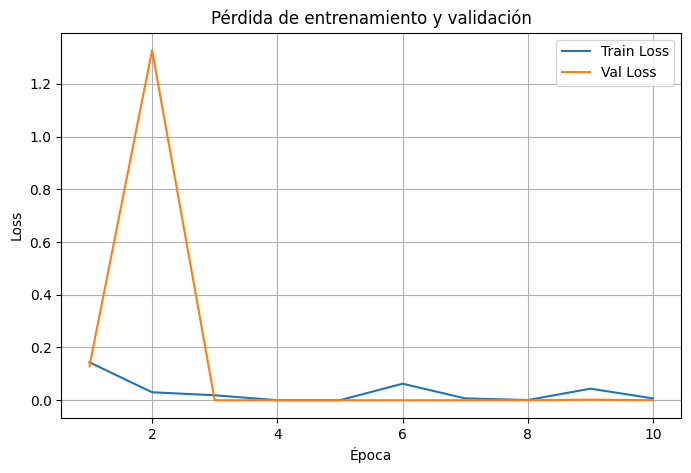

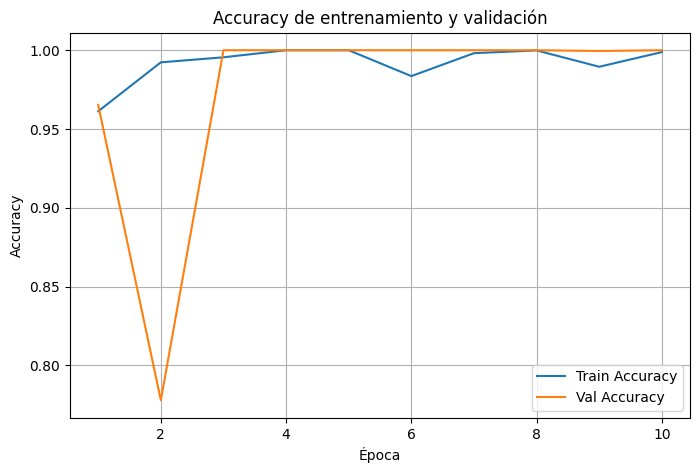

In [10]:
# =========================================================
# Graficar métricas del entrenamiento
# =========================================================
plot_training_history(history, save_dir=FIGURES_DIR)

## 11. Cargar el mejor modelo guardado

Aunque ya tenemos el modelo en memoria, aquí volvemos a cargar el modelo
desde el archivo `.pth` guardado en disco.

Esto demuestra que el proceso de serialización del modelo funciona correctamente.


In [11]:
# =========================================================
# Reconstruir el modelo y cargar pesos guardados
# =========================================================
best_model = build_model(
    num_classes=NUM_CLASSES,
    use_pretrained=False,   # ya no necesitamos pesos de ImageNet si cargaremos los nuestros
    freeze_backbone=False
)

best_model = load_model_weights(
    model=best_model,
    weights_path=MODEL_SAVE_PATH,
    device=device
)

print("✅ Mejor modelo cargado correctamente desde disco")

✅ Mejor modelo cargado correctamente desde disco


## 12. Mostrar imágenes clasificadas

El entregable del proyecto pide incluir una sección donde se muestre una imagen
clasificada para evidenciar que el modelo está haciendo su trabajo.

En esta sección se muestran varias imágenes del dataset junto con:

- la etiqueta real,
- y la predicción del modelo.


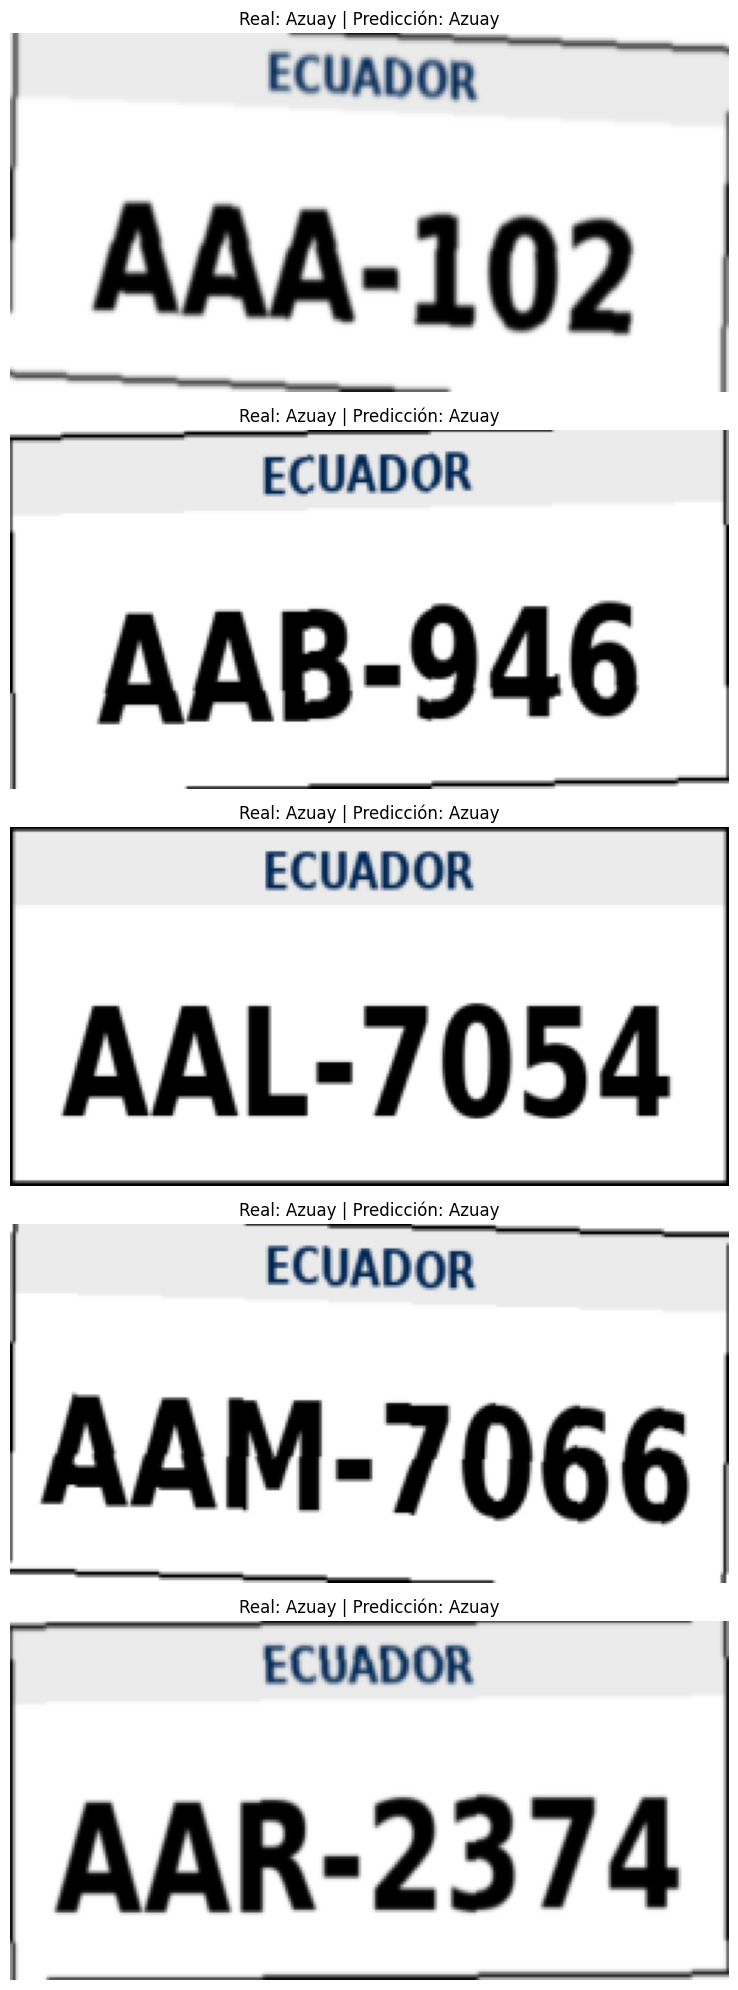

In [12]:
# =========================================================
# Mostrar predicciones del modelo sobre imágenes del dataset
# =========================================================
show_predictions(
    model=best_model,
    dataset=test_dataset,
    device=device,
    index_to_province=INDEX_TO_PROVINCE,
    num_images=5
)

## 13. Predicción individual paso a paso

Además de mostrar varias imágenes, también es útil inspeccionar una sola imagen
y revisar explícitamente su clase real y su clase predicha.


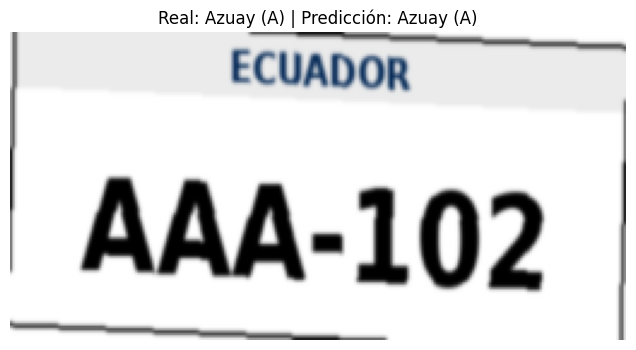

Etiqueta real:      0 - Azuay
Etiqueta predicha:  0 - Azuay


In [13]:
# =========================================================
# Probar una predicción individual
# =========================================================
index = 0

image, real_label = test_dataset[index]

best_model.eval()
with torch.no_grad():
    output = best_model(image.unsqueeze(0).to(device))
    pred_label = torch.argmax(output, dim=1).item()

image_np = image.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(8, 4))
plt.imshow(image_np)
plt.axis("off")
plt.title(
    f"Real: {INDEX_TO_PROVINCE[real_label]} ({INDEX_TO_LETTER[real_label]}) | "
    f"Predicción: {INDEX_TO_PROVINCE[pred_label]} ({INDEX_TO_LETTER[pred_label]})"
)
plt.show()

print("Etiqueta real:     ", real_label, "-", INDEX_TO_PROVINCE[real_label])
print("Etiqueta predicha: ", pred_label, "-", INDEX_TO_PROVINCE[pred_label])

## 14. Resumen final

En este notebook se implementó un pipeline completo de clasificación de placas:

- se cargó un dataset sintético de placas,
- se construyó un modelo ResNet18 adaptado a 24 clases,
- se entrenó el modelo,
- se visualizaron métricas,
- y se mostraron ejemplos de clasificación.

### Entregables cubiertos
- **Train**: notebook con entrenamiento y métricas visibles.
- **Utils**: uso de archivos auxiliares para dataset, modelo y entrenamiento.
- **Modelo serializado**: guardado en `outputs/models/best_model.pth`.

### Próximas mejoras posibles
- usar matriz de confusión,
- probar más augmentations,
- ajustar learning rate,
- probar otras arquitecturas como MobileNet o EfficientNet.
